# DAPPC – LAB 1
## Hierarchical Clustering-based Missing Value Imputation

In this notebook you will:

1. Load a prepared dataset  
2. Explore missing values  
3. Apply Hierarchical Clustering-based imputation  
5. Save the imputed dataset

We assume:
- The dataset is already cleaned (columns/rows filtered)
- Outcome has 3 classes (0,1,2)

## 0) Setup


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

## 1) Load Dataset


In [ ]:
import pandas as pd

file_path = "/content/Dataset_DAPPC_2026.xlsx"
sheet_name = "Dataset_v1"

df = pd.read_excel(file_path, sheet_name=sheet_name)

print("Initial shape:", df.shape)
df.head()

Initial shape: (3893, 76)


,subject_id,hadm_id,stay_id,ICU,ICU_intime,ICU_outtime,gender,age,weight,charlson_comorbidity_index,...,first_plateau_pressure,std_plateau_pressure,vent_duration_hours,outcome,comorb_total,comorb_catcardiac_cardiovascular,comorb_catrespiratory_pulmonary,comorb_catmetabolic_endocrine_renal,comorb_catneurological_neuromuscular_psychiatric,comorb_catsystemic_immune_oncologic
0,13710366,26676995,36043579,1,2172-04-05 04:00:00,2172-04-09 08:17:22,1,66,113.3,3,...,19.0,1.909727,96.0,2,1,0,0,1,0,0
1,12970079,23949170,36004625,1,2164-12-22 19:48:19,2165-01-03 21:30:54,1,53,106.7,5,...,10.0,8.337289,230.0,1,5,0,1,1,0,0
2,17682100,22097504,34901461,1,2173-08-23 01:12:00,2173-08-27 21:28:52,0,66,46.1,6,...,17.0,1.224745,34.0,1,4,0,0,1,0,0
3,15545849,24922530,39025631,3,2172-08-02 16:32:00,2172-09-09 12:44:11,1,49,106.0,1,...,11.0,4.877563,399.0,2,4,1,0,1,1,0
4,10288279,21750307,34078845,1,2114-09-07 20:19:42,2114-09-15 13:24:09,0,77,49.3,7,...,17.0,3.239768,155.0,2,4,1,0,1,0,1


## 2) Column Index Table


In [ ]:
import numpy as np

if 'outcome' in df.columns:
    outcome_col = df.pop('outcome')
    df['outcome'] = outcome_col

display(pd.DataFrame({
    "index": np.arange(df.shape[1]),
    "column_name": df.columns,
    "dtype": df.dtypes
}))

,index,column_name,dtype
subject_id,0,subject_id,int64
hadm_id,1,hadm_id,int64
stay_id,2,stay_id,int64
ICU,3,ICU,int64
ICU_intime,4,ICU_intime,object
...,...,...,...
comorb_catrespiratory_pulmonary,71,comorb_catrespiratory_pulmonary,int64
comorb_catmetabolic_endocrine_renal,72,comorb_catmetabolic_endocrine_renal,int64
comorb_catneurological_neuromuscular_psychiatric,73,comorb_catneurological_neuromuscular_psychiatric,int64
comorb_catsystemic_immune_oncologic,74,comorb_catsystemic_immune_oncologic,int64


## 3) Explore Missing Values

In [ ]:
# Total missing values (global)
print("Total missing values:", df.isna().sum().sum())

# Missing per column: count + percentage
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2)
})

# Display only columns with at least one missing value
missing_table = missing_table[missing_table["missing_count"] > 0] \
                    .sort_values("missing_%", ascending=False)

display(missing_table)

Total missing values: 0


,missing_count,missing_%


## 4) Apply Hierarchical clustering-based Imputation

Adopting hierarchical clustering as MVs imputations works as follows:
1. Identify input features (Only clinically meaningful numeric variables should be imputed) and their type (continous, categorical or integer);
2. Define the TRS (subjects without any missing value)
3. Data normalization (min-max scaling applied to the TRS);
4. Dendrogram construction (linkage and dendrogram functions);
5. Cluster identifications (cut the dendrogram and assign the subjects of the TRS to their cluster);
6. Centroids computation (for each cluster compute the centroid);
7. For each subject with at least one MV:
   
   a) Compute the distances wit the centroids;
   
   b) Assign the subject with MVs to its cluster (the closest one);
   
   c) Impute the MVs according to the type of feature (mean value + noise  for continous variables, random value between the 40th and 60th percentile for integer variables, majority voting for categorical variables).

Notes:
- The centroids and the distances must be computed on the normalized data.
- The imputation must be performed on the original values of the features (not the normalized ones!).
- Try to cut the dendrogram in order to obtain between 30 and 35 clusters.

In [ ]:
import numpy as np

# ============================================================
# 1. Define variable groups: classify features by type
# ============================================================

# Exclude identifier, datetime, and outcome columns
exclude_cols = [
    'subject_id',
    'hadm_id',
    'stay_id',
    'ICU_intime',
    'ICU_outtime',
    'outcome'
]

# Initialize lists
continuous_vars = []
integer_vars = []
categorical_vars = []

# Iterate through columns to classify them
for col in df.columns:
    if col in exclude_cols:
        continue

    if df[col].dtype == 'float64':
        continuous_vars.append(col)
    elif df[col].dtype == 'int64':
        # Heuristic for distinguishing integer numerical from categorical
        # Consider columns with low unique values or specific names as categorical
        if col in ['age', 'charlson_comorbidity_index', 'comorb_total']:
            integer_vars.append(col)
        elif col in ['ICU', 'gender', 'admission_type', 'first_hosp_stay'] or 'comorb_cat' in col:
            categorical_vars.append(col)
        else:
            # Default to integer if not explicitly categorized and not float
            integer_vars.append(col)

input_features = continuous_vars + integer_vars + categorical_vars

print("Continuous Variables (", len(continuous_vars), "):", continuous_vars)
print("Integer Variables (", len(integer_vars), "):", integer_vars)
print("Categorical Variables (", len(categorical_vars), "):", categorical_vars)
print("Total input features for imputation (", len(input_features), "):", input_features)

Continuous Variables ( 46 ): ['weight', 'first_pCO2', 'std_pCO2', 'first_pH', 'std_pH', 'first_pO2', 'std_pO2', 'first_PT', 'std_PT', 'first_PTT', 'std_PTT', 'std_chloride', 'first_creatinine', 'std_creatinine', 'first_glycemia', 'std_glycemia', 'first_hemoglobin', 'std_hemoglobin', 'first_phosphate', 'std_phosphate', 'std_platelets', 'first_potassium', 'std_potassium', 'std_sodium', 'first_wbc', 'std_wbc', 'std_diastolic_blood_pressure', 'first_mean_blood_pressure', 'std_mean_blood_pressure', 'first_systolic_blood_pressure', 'std_systolic_blood_pressure', 'first_heart_rate', 'std_heart_rate', 'first_respiratory_rate', 'std_respiratory_rate', 'first_temperature', 'std_temperature', 'first_PEEP', 'std_PEEP', 'first_PIP', 'std_PIP', 'first_mean_airway_pressure', 'std_mean_airway_pressure', 'first_plateau_pressure', 'std_plateau_pressure', 'vent_duration_hours']
Integer Variables ( 17 ): ['age', 'charlson_comorbidity_index', 'gcs', 'sofa', 'sirs', 'sapsii', 'vasopressors', 'sedatives', 'n

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler # Added for NameError fix

# ============================================================
# 2. Split subjects into:
#    - TRS: subjects without missing values
#    - subjects with missing values
# ============================================================
X = df[input_features].copy()

# Print total NaN values in X to confirm why X_missing is empty
print("Total NaN values in input features (X):", X.isna().sum().sum())

X_trs = X.dropna() # Dataframe with subjects of TRS and ONLY input features
X_missing = X[X.isna().any(axis=1)] # Dataframe with subjects with MVs and ONLY input features

# Check how any subjects are in each set
print("TRS subjects:", X_trs.shape[0])
print("Subjects with MVs:", X_missing.shape[0])

# ============================================================
# 3. Normalize TRS subjects
# ============================================================
scaler = MinMaxScaler()

X_trs_scaled = pd.DataFrame(
    scaler.fit_transform(X_trs),
    columns=X_trs.columns,
    index=X_trs.index
)

Total NaN values in input features (X): 0
TRS subjects: 3893
Subjects with MVs: 0


{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [55.0, 55.0, 65.0, 65.0],
  [45.0, 45.0, 60.0, 60.0],
  [35.0, 35.0, 52.5, 52.5],
  [85.0, 85.0, 95.0, 95.0],
  [75.0, 75.0, 90.0, 90.0],
  [125.0, 125.0, 135.0, 135.0],
  [115.0, 115.0, 130.0, 130.0],
  [105.0, 105.0, 122.5, 122.5],
  [82.5, 82.5, 113.75, 113.75],
  [43.75, 43.75, 98.125, 98.125],
  [165.0, 165.0, 175.0, 175.0],
  [155.0, 155.0, 170.0, 170.0],
  [145.0, 145.0, 162.5, 162.5],
  [205.0, 205.0, 215.0, 215.0],
  [195.0, 195.0, 210.0, 210.0],
  [185.0, 185.0, 202.5, 202.5],
  [235.0, 235.0, 245.0, 245.0],
  [225.0, 225.0, 240.0, 240.0],
  [255.0, 255.0, 265.0, 265.0],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [260.0, 260.0, 282.5, 282.5],
  [232.5, 232.5, 271.25, 271.25],
  [193.75, 193.75, 251.875, 251.875],
  [153.75, 153.75, 222.8125, 222.8125],
  [70.9375, 70.9375, 188.28125, 188.28125],
  [12.5, 12.5, 129.609375, 129.609375]],
 'dcoord': [[0.0,
   np.float64(10.284889356177278),


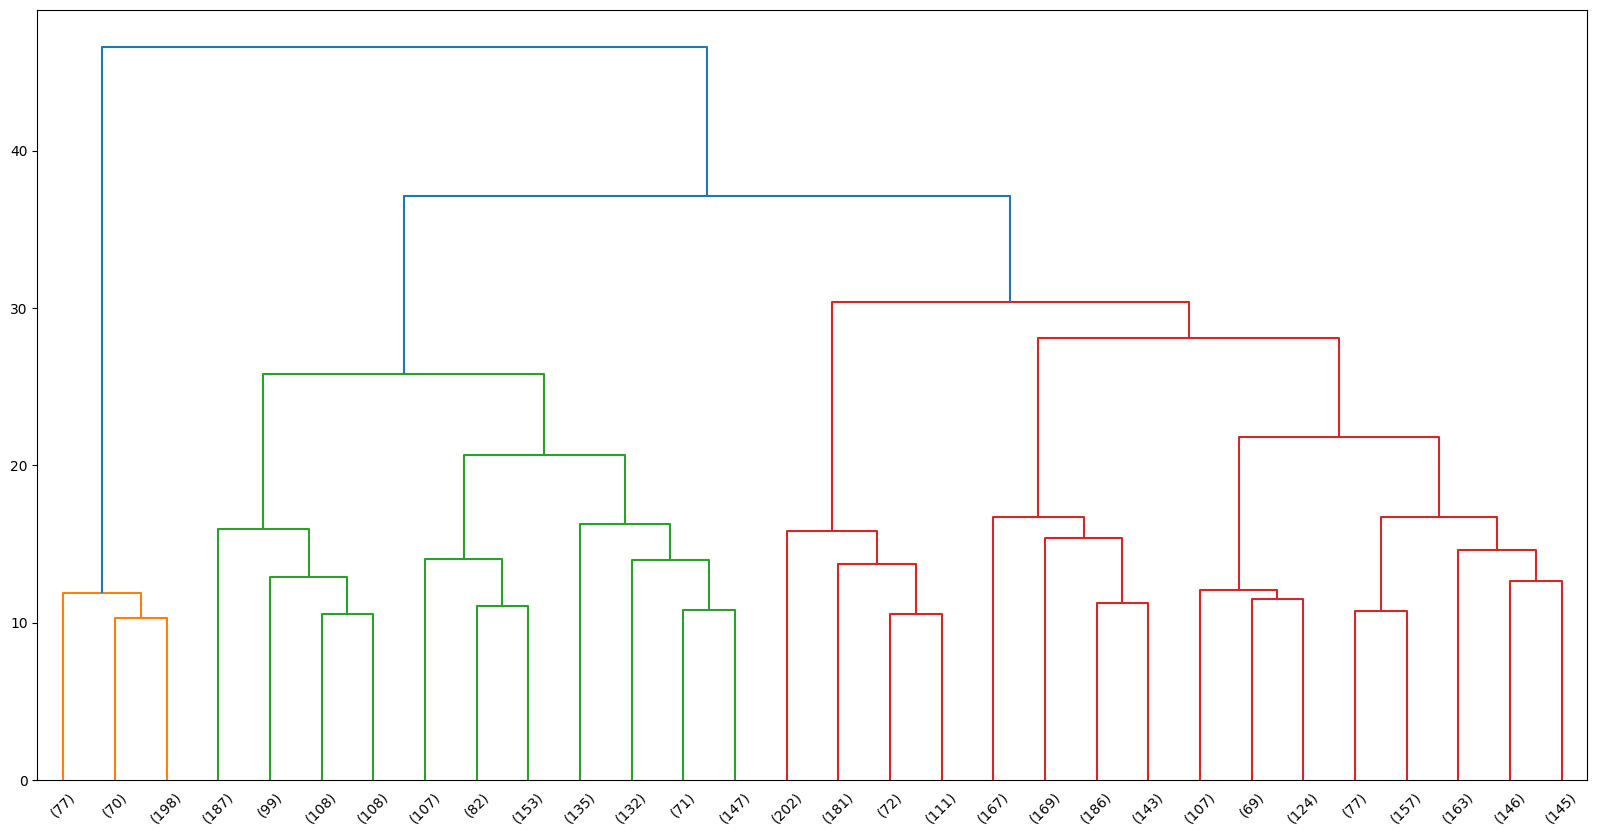

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, dendrogram

# Apply clustering-based imputation
# Helpful functions and classes:
# - linkage
# - dendrogram
# - fcluster

# ============================================================
# 4. Construct the dendrogram using normalized data
# ============================================================
Z = linkage(X_trs_scaled, method='ward')

plt.figure(figsize=(20, 10))
dendrogram(Z, truncate_mode='lastp', p=30)

In [ ]:
import numpy as np
# ============================================================
# 5. Identify clusters in the TRS
# ============================================================
n_clusters = 30 # As per instructions, aim for 30-35 clusters
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')

X_trs_scaled["cluster"] = cluster_labels
X_trs["cluster"] = cluster_labels

print("Number of clusters found:", len(np.unique(cluster_labels)))

Number of clusters found: 30


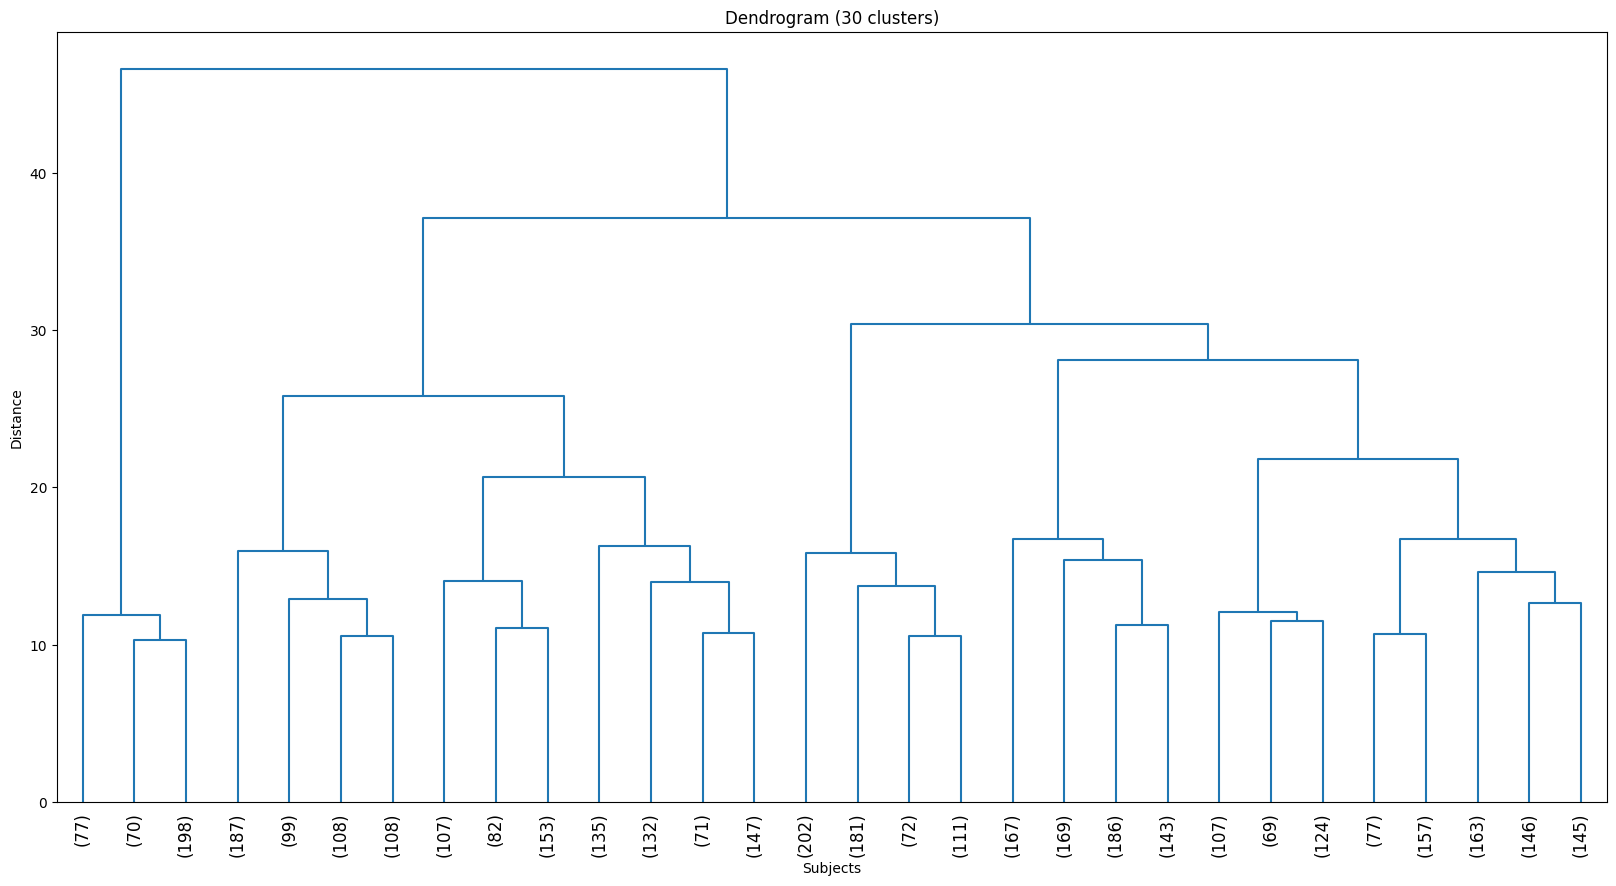

In [ ]:
import numpy as np
# ============================================================
# Look the dendrogram with clusters defined
# ============================================================
plt.figure(figsize=(20, 10))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=n_clusters, # display only the last 'p' merged clusters
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=12.,  # fontsize for the x axis labels
    color_threshold=Z[-(n_clusters-1), 2]
)
plt.title(f"Dendrogram ({n_clusters} clusters)")
plt.xlabel("Subjects")
plt.ylabel("Distance")
plt.show()

In [ ]:
X_trs_scaled["cluster"] = cluster_labels
X_trs["cluster"] = cluster_labels
centroids_scaled = X_trs_scaled.groupby('cluster').mean()

In [ ]:
import numpy as np

# ============================================================
# 7. Impute subjects with missing values
# ============================================================
X_imputed = X.copy()

# Loop over subjects with missing values
for subject_idx in X_missing.index:

    # Current subject
    subject = X.loc[subject_idx]

    # Normalize subject using scaler fitted on TRS
    # Only transform non-missing values for distance calculation
    subject_scaled_temp = subject.dropna().to_frame().T
    subject_scaled_temp = pd.DataFrame(
        scaler.transform(subject_scaled_temp),
        columns=subject_scaled_temp.columns,
        index=[subject_idx]
    )

    # Keep only observed (non NAN) variables from the scaled subject
    observed_vars = subject.dropna().index.tolist()

    # Compare subject and centroids only on observed variables
    subject_observed = subject_scaled_temp.loc[subject_idx, observed_vars]
    centroids_observed = centroids_scaled[observed_vars]

    # Manhattan distance from all centroids (using ord=1)
    distances = centroids_observed.apply(lambda centroid: np.linalg.norm(subject_observed - centroid, ord=1), axis=1)

    # Identify the closest cluster
    closest_cluster = distances.idxmin()

    # Extract subjects of that cluster from the original (non-scaled) TRS data
    cluster_subjects = X_trs[X_trs['cluster'] == closest_cluster].drop(columns=['cluster'])

    # Identify missing variables for the current subject
    missing_vars = subject.loc[subject.isna()].index.tolist()

    # Impute MVs according to the type of each feature
    for var in missing_vars:
        if var in continuous_vars:
            # Impute with mean + noise
            mean_val = cluster_subjects[var].mean()
            std_val = cluster_subjects[var].std()
            # Add a small random noise, proportional to the std dev if available
            imputed_value = mean_val + np.random.normal(0, std_val * 0.1) if not pd.isna(std_val) and std_val > 0 else mean_val

            # Clip to the cluster's range to avoid out-of-bounds values
            min_val = cluster_subjects[var].min()
            max_val = cluster_subjects[var].max()
            imputed_value = np.clip(imputed_value, min_val, max_val)

            X_imputed.loc[subject_idx, var] = imputed_value
        elif var in integer_vars:
            # Impute with random value between 40th and 60th percentile
            lower_bound = cluster_subjects[var].quantile(0.40)
            upper_bound = cluster_subjects[var].quantile(0.60)
            # Fallback to mode or mean if percentiles are problematic
            if pd.isna(lower_bound) or pd.isna(upper_bound) or upper_bound < lower_bound:
                # Use mode if available, otherwise mean (rounded for integer)
                imputed_value = cluster_subjects[var].mode()[0] if not cluster_subjects[var].mode().empty else cluster_subjects[var].mean()
            else:
                imputed_value = np.random.uniform(lower_bound, upper_bound)
            X_imputed.loc[subject_idx, var] = round(imputed_value)
        elif var in categorical_vars:
            # Impute with mode (majority voting)
            imputed_value = cluster_subjects[var].mode()[0]
            X_imputed.loc[subject_idx, var] = imputed_value

# ============================================================
# 8. Rebuild final dataset
# ============================================================
df_final = df.copy()
df_final[input_features] = X_imputed[input_features]

In [ ]:
print("Shape of df_final:", df_final.shape)
print("Total missing values in df_final:", df_final.isna().sum().sum())
display(df_final.head())

Shape of df_final: (3893, 76)
Total missing values in df_final: 0


,subject_id,hadm_id,stay_id,ICU,ICU_intime,ICU_outtime,gender,age,weight,charlson_comorbidity_index,...,first_plateau_pressure,std_plateau_pressure,vent_duration_hours,comorb_total,comorb_catcardiac_cardiovascular,comorb_catrespiratory_pulmonary,comorb_catmetabolic_endocrine_renal,comorb_catneurological_neuromuscular_psychiatric,comorb_catsystemic_immune_oncologic,outcome
0,13710366,26676995,36043579,1,2172-04-05 04:00:00,2172-04-09 08:17:22,1,66,113.3,3,...,19.0,1.909727,96.0,1,0,0,1,0,0,2
1,12970079,23949170,36004625,1,2164-12-22 19:48:19,2165-01-03 21:30:54,1,53,106.7,5,...,10.0,8.337289,230.0,5,0,1,1,0,0,1
2,17682100,22097504,34901461,1,2173-08-23 01:12:00,2173-08-27 21:28:52,0,66,46.1,6,...,17.0,1.224745,34.0,4,0,0,1,0,0,1
3,15545849,24922530,39025631,3,2172-08-02 16:32:00,2172-09-09 12:44:11,1,49,106.0,1,...,11.0,4.877563,399.0,4,1,0,1,1,0,2
4,10288279,21750307,34078845,1,2114-09-07 20:19:42,2114-09-15 13:24:09,0,77,49.3,7,...,17.0,3.239768,155.0,4,1,0,1,0,1,2


## 5) Final saving

In [ ]:
new_sheet_name = "Dataset_step_3c"

with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_final.to_excel(writer, sheet_name=new_sheet_name, index=False)

print(f"Dataset saved to new sheet: '{new_sheet_name}' in '{file_path}'")

Dataset saved to new sheet: 'Dataset_step_3c' in '/content/Dataset_DAPPC_2026.xlsx'


---
## Hierarchical Clustering-based Missing Value Imputation by Outcome Class

In this section we perform clustering-based imputation **separately for each outcome class (0 / 1 / 2)**.

Why?
- Patients from different outcome classes may have different clinical distributions.
- Imputing within class preserves intra-class similarity.


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, fcluster

# Make a copy of the original DataFrame to work with
df_imputed_by_class = df.copy()

# Initialize an empty list to store imputed dataframes for each class
imputed_dfs_by_class = []

# Get unique outcome classes
outcome_classes = df['outcome'].unique()

# Define the number of clusters for each class
n_clusters_by_class = {
    0: 20,
    1: 25,
    2: 25
}

print(f"Imputing for outcome classes: {outcome_classes}")

for outcome_class in sorted(outcome_classes):
    print(f"\n--- Processing outcome class: {outcome_class} ---")

    # 1. Split patients by outcome class
    df_class = df[df['outcome'] == outcome_class].copy()

    # Select only input features for this class
    X_class = df_class[input_features].copy()

    # 2. Split into TRS and subjects with missing values for the current class
    X_trs_class = X_class.dropna()
    X_missing_class = X_class[X_class.isna().any(axis=1)]

    print(f"Class {outcome_class} - TRS subjects: {X_trs_class.shape[0]}")
    print(f"Class {outcome_class} - Subjects with MVs: {X_missing_class.shape[0]}")

    if X_trs_class.empty and not X_missing_class.empty:
        print(f"Warning: No TRS available for class {outcome_class} to build centroids. Skipping imputation for this class.")
        imputed_dfs_by_class.append(df_class)
        continue
    elif X_missing_class.empty:
        print(f"No missing values found in class {outcome_class}. Appending original data.")
        imputed_dfs_by_class.append(df_class)
        continue

    # 3. Data normalization (min-max scaling applied to the TRS)
    scaler_class = MinMaxScaler()
    X_trs_scaled_class = pd.DataFrame(
        scaler_class.fit_transform(X_trs_class),
        columns=X_trs_class.columns,
        index=X_trs_class.index
    )

    # 4. Dendrogram construction using normalized data (linkage function)
    # Check for enough samples to perform clustering
    if X_trs_scaled_class.shape[0] < 2:
        print(f"Not enough samples in TRS for class {outcome_class} to perform clustering. Skipping imputation.")
        imputed_dfs_by_class.append(df_class)
        continue

    Z_class = linkage(X_trs_scaled_class, method='ward')

    # 5. Cluster identifications (cut the dendrogram and assign the subjects of the TRS to their cluster)
    # Define the target number of clusters for this class
    target_clusters = n_clusters_by_class.get(outcome_class, 25)
    # Ensure we don't request more clusters than available samples
    n_clusters_class = min(target_clusters, X_trs_class.shape[0] - 1)
    if n_clusters_class < 2:
        print(f"Not enough data points in TRS for class {outcome_class} to form multiple clusters. Skipping imputation.")
        imputed_dfs_by_class.append(df_class)
        continue

    cluster_labels_class = fcluster(Z_class, n_clusters_class, criterion='maxclust')

    X_trs_scaled_class["cluster"] = cluster_labels_class
    X_trs_class["cluster"] = cluster_labels_class

    actual_clusters = len(np.unique(cluster_labels_class))
    print(f"Class {outcome_class} - Number of clusters found: {actual_clusters}")

    # 6. Centroids computation
    centroids_scaled_class = X_trs_scaled_class.groupby('cluster').mean()

    # Initialize X_imputed_class for the current class's features
    X_imputed_class = X_class.copy()

    # 7. For each subject with at least one MV:
    for subject_idx in X_missing_class.index:
        subject = X_class.loc[subject_idx]

        # Normalize subject using scaler fitted on TRS (only non-missing values for distance calculation)
        subject_scaled_temp = subject.dropna().to_frame().T
        if not subject_scaled_temp.empty:
            subject_scaled_temp = pd.DataFrame(
                scaler_class.transform(subject_scaled_temp),
                columns=subject_scaled_temp.columns,
                index=[subject_idx]
            )
        else:
            # If all values are NaN for a subject, skip as the problem implies at least some observed values
            print(f"Warning: Subject {subject_idx} in class {outcome_class} has all missing values. Skipping imputation for this subject.")
            continue

        observed_vars = subject.dropna().index.tolist()
        subject_observed = subject_scaled_temp.loc[subject_idx, observed_vars]
        centroids_observed = centroids_scaled_class[observed_vars]

        # Manhattan distance from all centroids
        distances = centroids_observed.apply(lambda centroid: np.linalg.norm(subject_observed - centroid, ord=1), axis=1)

        # Identify the closest cluster
        closest_cluster = distances.idxmin()

        # Extract subjects of that cluster from the original (non-scaled) TRS data
        cluster_subjects = X_trs_class[X_trs_class['cluster'] == closest_cluster].drop(columns=['cluster'])

        # Identify missing variables for the current subject
        missing_vars = subject.loc[subject.isna()].index.tolist()

        # Impute MVs according to the type of each feature
        for var in missing_vars:
            if var in continuous_vars:
                mean_val = cluster_subjects[var].mean()
                std_val = cluster_subjects[var].std()
                imputed_value = mean_val + np.random.normal(0, std_val * 0.1) if not pd.isna(std_val) and std_val > 0 else mean_val

                # Clip to the cluster's range to avoid out-of-bounds values
                min_val = cluster_subjects[var].min()
                max_val = cluster_subjects[var].max()
                imputed_value = np.clip(imputed_value, min_val, max_val)

                X_imputed_class.loc[subject_idx, var] = imputed_value
            elif var in integer_vars:
                lower_bound = cluster_subjects[var].quantile(0.40)
                upper_bound = cluster_subjects[var].quantile(0.60)
                if pd.isna(lower_bound) or pd.isna(upper_bound) or upper_bound < lower_bound:
                    imputed_value = cluster_subjects[var].mode()[0] if not cluster_subjects[var].mode().empty else cluster_subjects[var].mean()
                else:
                    imputed_value = np.random.uniform(lower_bound, upper_bound)
                X_imputed_class.loc[subject_idx, var] = round(imputed_value)
            elif var in categorical_vars:
                if not cluster_subjects[var].mode().empty:
                    imputed_value = cluster_subjects[var].mode()[0]
                    X_imputed_class.loc[subject_idx, var] = imputed_value
                else:
                    # Fallback if mode is empty (e.g., all NaNs in cluster for this var)
                    X_imputed_class.loc[subject_idx, var] = df[var].mode()[0]

    # Update the full df_class with imputed features
    df_class[input_features] = X_imputed_class[input_features]
    imputed_dfs_by_class.append(df_class)

# Concatenate all imputed subsets
df_final_by_class = pd.concat(imputed_dfs_by_class).sort_index()

print("\n--- Imputation by class complete ---")
print("Shape of df_final_by_class:", df_final_by_class.shape)
print("Total missing values in df_final_by_class:", df_final_by_class.isna().sum().sum())
display(df_final_by_class.head())

Imputing for outcome classes: [2 1 0]

--- Processing outcome class: 0 ---
Class 0 - TRS subjects: 776
Class 0 - Subjects with MVs: 0
No missing values found in class 0. Appending original data.

--- Processing outcome class: 1 ---
Class 1 - TRS subjects: 1948
Class 1 - Subjects with MVs: 0
No missing values found in class 1. Appending original data.

--- Processing outcome class: 2 ---
Class 2 - TRS subjects: 1169
Class 2 - Subjects with MVs: 0
No missing values found in class 2. Appending original data.

--- Imputation by class complete ---
Shape of df_final_by_class: (3893, 76)
Total missing values in df_final_by_class: 0


,subject_id,hadm_id,stay_id,ICU,ICU_intime,ICU_outtime,gender,age,weight,charlson_comorbidity_index,...,first_plateau_pressure,std_plateau_pressure,vent_duration_hours,comorb_total,comorb_catcardiac_cardiovascular,comorb_catrespiratory_pulmonary,comorb_catmetabolic_endocrine_renal,comorb_catneurological_neuromuscular_psychiatric,comorb_catsystemic_immune_oncologic,outcome
0,13710366,26676995,36043579,1,2172-04-05 04:00:00,2172-04-09 08:17:22,1,66,113.3,3,...,19.0,1.909727,96.0,1,0,0,1,0,0,2
1,12970079,23949170,36004625,1,2164-12-22 19:48:19,2165-01-03 21:30:54,1,53,106.7,5,...,10.0,8.337289,230.0,5,0,1,1,0,0,1
2,17682100,22097504,34901461,1,2173-08-23 01:12:00,2173-08-27 21:28:52,0,66,46.1,6,...,17.0,1.224745,34.0,4,0,0,1,0,0,1
3,15545849,24922530,39025631,3,2172-08-02 16:32:00,2172-09-09 12:44:11,1,49,106.0,1,...,11.0,4.877563,399.0,4,1,0,1,1,0,2
4,10288279,21750307,34078845,1,2114-09-07 20:19:42,2114-09-15 13:24:09,0,77,49.3,7,...,17.0,3.239768,155.0,4,1,0,1,0,1,2


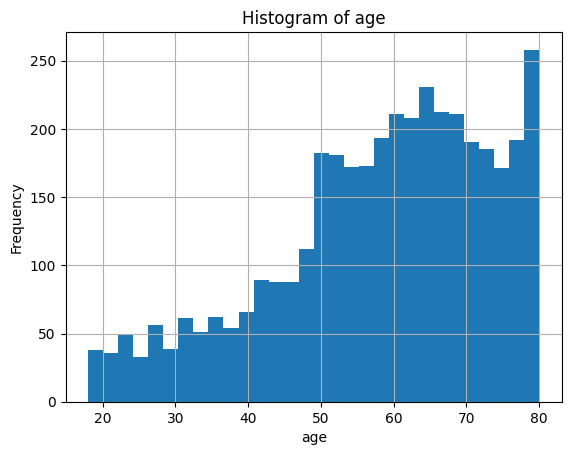

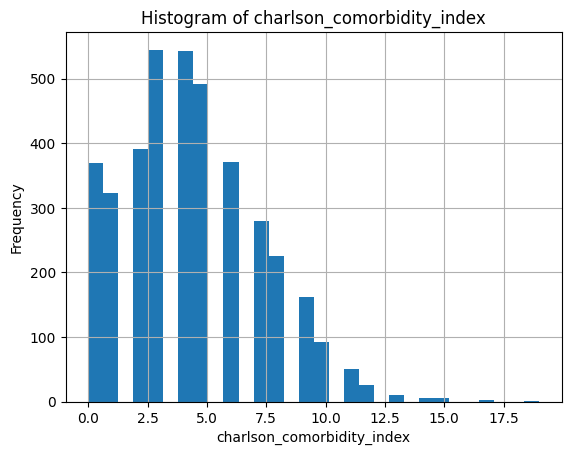

In [ ]:
import matplotlib.pyplot as plt

continuous_vars_to_plot = ['age', 'charlson_comorbidity_index']  # Select the most important variables

for col in continuous_vars_to_plot:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## Final saving

In [ ]:
# Save the imputed dataset (clustering by class) into a new Excel sheet
new_sheet_name = "Dataset_step_3d"

with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_final_by_class.to_excel(writer, sheet_name=new_sheet_name, index=False)

print(f"Dataset saved to new sheet: '{new_sheet_name}' in '{file_path}'")

Dataset saved to new sheet: 'Dataset_step_3d' in '/content/Dataset_DAPPC_2026.xlsx'
